# Buy Into the Gaps?

*A trade worth watching. A question worth answering. 7 years of futures data.*

**Hernan Rosenblum** · June 2026


In [1]:
# Find repo root regardless of where the notebook is opened
import os
while not os.path.exists("data") and os.getcwd() != "/":
    os.chdir("..")

import warnings, datetime
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

BG    = "#0d1117"
GREEN = "#3fb950"
BLUE  = "#58a6ff"
GOLD  = "#e3b341"
RED   = "#f78166"
GREY  = "#8b949e"
WHITE = "#f0f6fc"

plt.style.use("dark_background")
plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "axes.edgecolor": GREY, "axes.labelcolor": WHITE, "text.color": WHITE,
    "xtick.color": WHITE, "ytick.color": WHITE,
    "figure.dpi": 130, "font.size": 11, "font.family": "sans-serif",
})
os.makedirs("charts", exist_ok=True)

es = pd.read_csv("data/ES_1m_2019_2026.csv", parse_dates=["ts_event"]).set_index("ts_event")
es.index = pd.to_datetime(es.index, utc=True).tz_convert("America/New_York")
day = es[es.index.date == pd.Timestamp("2026-06-15").date()]
t = day.index.time
sess = day[(t >= datetime.time(9,30)) & (t <= datetime.time(16,0))]

ESU_PREV_CLOSE = 7498.50   # Friday Jun 12 RTH close
ESU_OPEN       = 7545.25   # Monday Jun 15 RTH open (the gap is here)
ESU_CLOSE      = 7620.50   # Jun 15 RTH close
ESU_HIGH       = 7648.75   # Jun 15 high

events    = pd.read_csv("cache/phase3_nkd_validate.csv")
# Broader US-only event table with eod_pnl for every cell (used for stratification chart)
us_events = pd.read_csv("cache/phase2_events_075.csv")


## The Trade That Started It

A trader I follow made a move on June 15. ES gapped up at the open. He sold a credit spread anchored right at the open price. Closed it a few hours later — kept nearly the full premium.

The setup left me staring at the chart:

> *Is there a systematic pattern behind this, or is it just calibrated experience?*

7 years of 1-min futures data was about to find out.


## What the Chart Showed

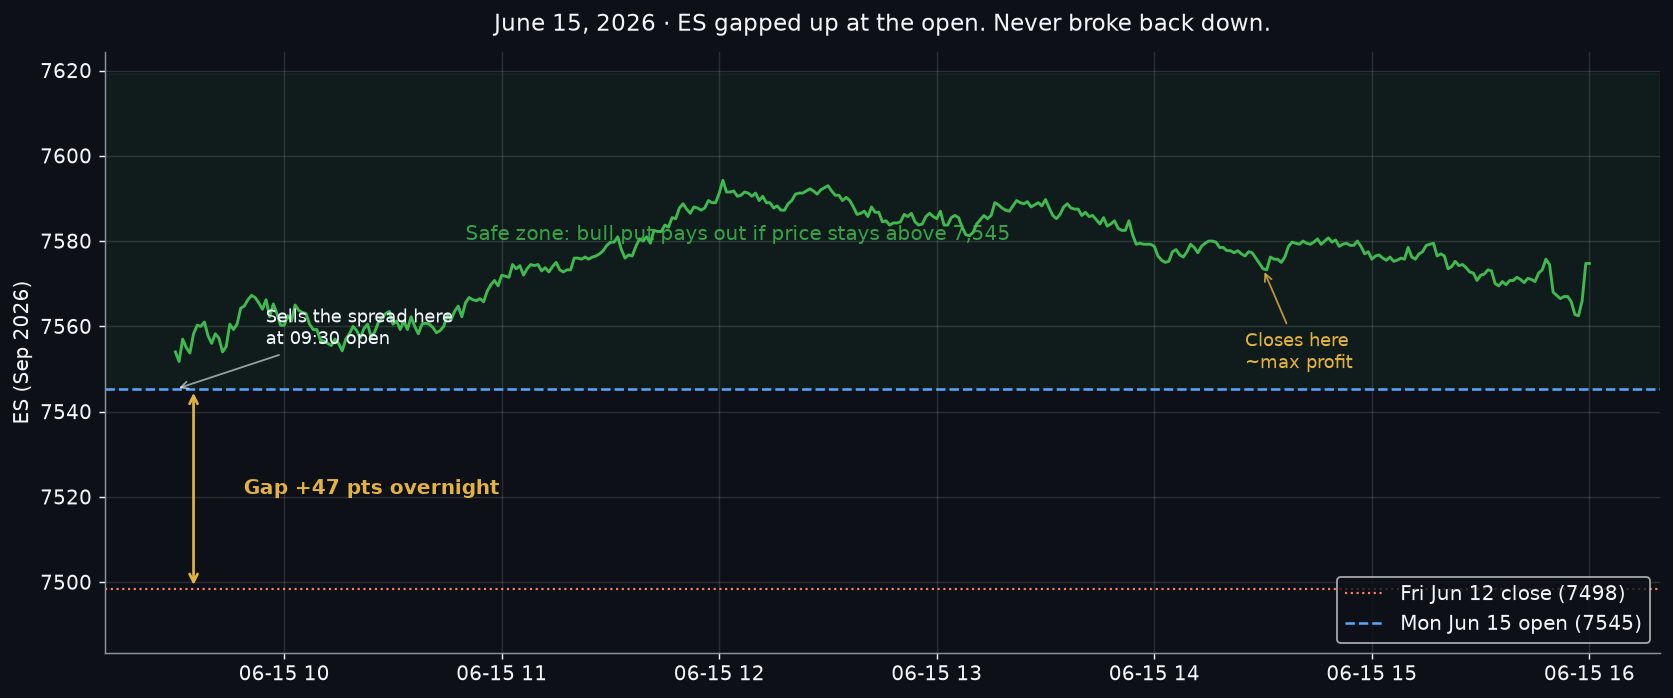

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))
shift = ESU_OPEN - float(sess.iloc[0]["open"])
adj = sess["close"] + shift

ax.plot(sess.index, adj, color=GREEN, lw=1.6)

# Previous day's close (the reference point that defines "the gap")
ax.axhline(ESU_PREV_CLOSE, color=RED, lw=1.2, ls=":",
           label=f"Fri Jun 12 close ({ESU_PREV_CLOSE:.0f})")
# The gap-up open / short-strike level
ax.axhline(ESU_OPEN, color=BLUE, lw=1.4, ls="--",
           label=f"Mon Jun 15 open ({ESU_OPEN:.0f})")
ax.axhspan(ESU_OPEN, adj.max() + 25, alpha=0.07, color=GREEN)

# Visual highlight of "the gap"
gap_pts = ESU_OPEN - ESU_PREV_CLOSE
ax.annotate("", xy=(sess.index[5], ESU_OPEN), xytext=(sess.index[5], ESU_PREV_CLOSE),
            arrowprops=dict(arrowstyle="<->", color=GOLD, lw=1.5))
ax.text(sess.index[15], (ESU_PREV_CLOSE + ESU_OPEN)/2,
        f"  Gap +{gap_pts:.0f} pts overnight",
        fontsize=11, color=GOLD, fontweight="bold", verticalalignment="center")

ax.annotate("Sells the spread here\nat 09:30 open",
            xy=(sess.index[0], ESU_OPEN),
            xytext=(50, 25), textcoords="offset points", fontsize=10, color=WHITE,
            arrowprops=dict(arrowstyle="->", color=WHITE, alpha=0.6))

cut_time = sess[sess.index.time == datetime.time(14,30)].index[0]
cut_px = float(adj.loc[cut_time])
ax.annotate("Closes here\n~max profit",
            xy=(cut_time, cut_px),
            xytext=(-10, -55), textcoords="offset points", fontsize=10, color=GOLD,
            arrowprops=dict(arrowstyle="->", color=GOLD, alpha=0.8))

ax.text(sess.index[80], ESU_OPEN + 35,
        "Safe zone: bull put pays out if price stays above 7,545",
        fontsize=11, color=GREEN, alpha=0.85)

ax.set_title("June 15, 2026 · ES gapped up at the open. Never broke back down.",
             fontsize=13, pad=12)
ax.set_ylabel("ES (Sep 2026)")
ax.legend(loc="lower right")
ax.grid(alpha=0.12)
ax.spines[["top","right"]].set_visible(False)
ax.set_ylim(ESU_PREV_CLOSE - 15, adj.max() + 30)
plt.tight_layout()
plt.savefig("charts/p11_01_jun15.png", dpi=140, bbox_inches="tight", facecolor=BG)
plt.show()


## Step 1 · How common is this pattern?

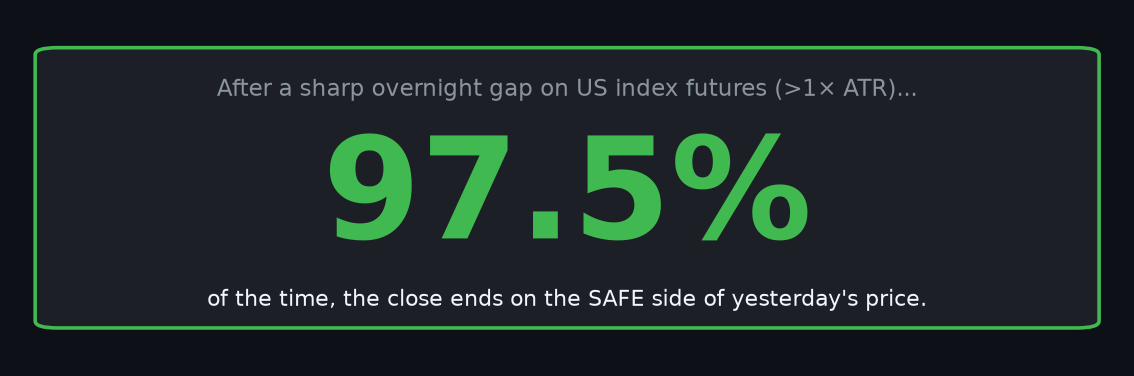

In [3]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.axis("off")
ax.add_patch(FancyBboxPatch((0.04, 0.12), 0.92, 0.76, boxstyle="round,pad=0.02",
                             facecolor="#1c2026", edgecolor=GREEN, linewidth=2,
                             transform=ax.transAxes))
ax.text(0.5, 0.78, "After a sharp overnight gap on US index futures (>1× ATR)...",
        ha="center", va="center", fontsize=13, color=GREY, transform=ax.transAxes)
ax.text(0.5, 0.46, "97.5%", ha="center", va="center",
        fontsize=78, color=GREEN, fontweight="bold", transform=ax.transAxes)
ax.text(0.5, 0.18, "of the time, the close ends on the SAFE side of yesterday's price.",
        ha="center", va="center", fontsize=12, color=WHITE, transform=ax.transAxes)
plt.savefig("charts/p11_02_pattern.png", dpi=140, bbox_inches="tight", facecolor=BG)
plt.show()


*Across 4 US index futures, 2019–2026, ~240 events.* The edge is real.
The next question is whether you can actually trade it.


## Step 2 · Try the obvious trade

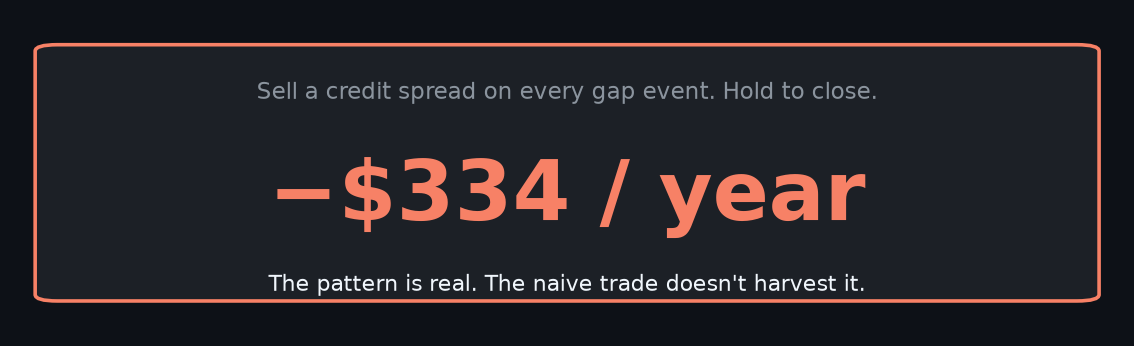

In [4]:
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.axis("off")
ax.add_patch(FancyBboxPatch((0.04, 0.12), 0.92, 0.76, boxstyle="round,pad=0.02",
                             facecolor="#1c2026", edgecolor=RED, linewidth=2,
                             transform=ax.transAxes))
ax.text(0.5, 0.75, "Sell a credit spread on every gap event. Hold to close.",
        ha="center", va="center", fontsize=13, color=GREY, transform=ax.transAxes)
ax.text(0.5, 0.42, "−$334 / year", ha="center", va="center",
        fontsize=46, color=RED, fontweight="bold", transform=ax.transAxes)
ax.text(0.5, 0.15, "The pattern is real. The naive trade doesn't harvest it.",
        ha="center", va="center", fontsize=12, color=WHITE, transform=ax.transAxes)
plt.savefig("charts/p11_03_naive.png", dpi=140, bbox_inches="tight", facecolor=BG)
plt.show()


The losers cost full max-loss. The winners only cap at 60% of credit. Asymmetric, in the wrong direction.

I'd need to find the *subset* of gap days where the edge actually concentrates.


## Step 3 · Slice the events

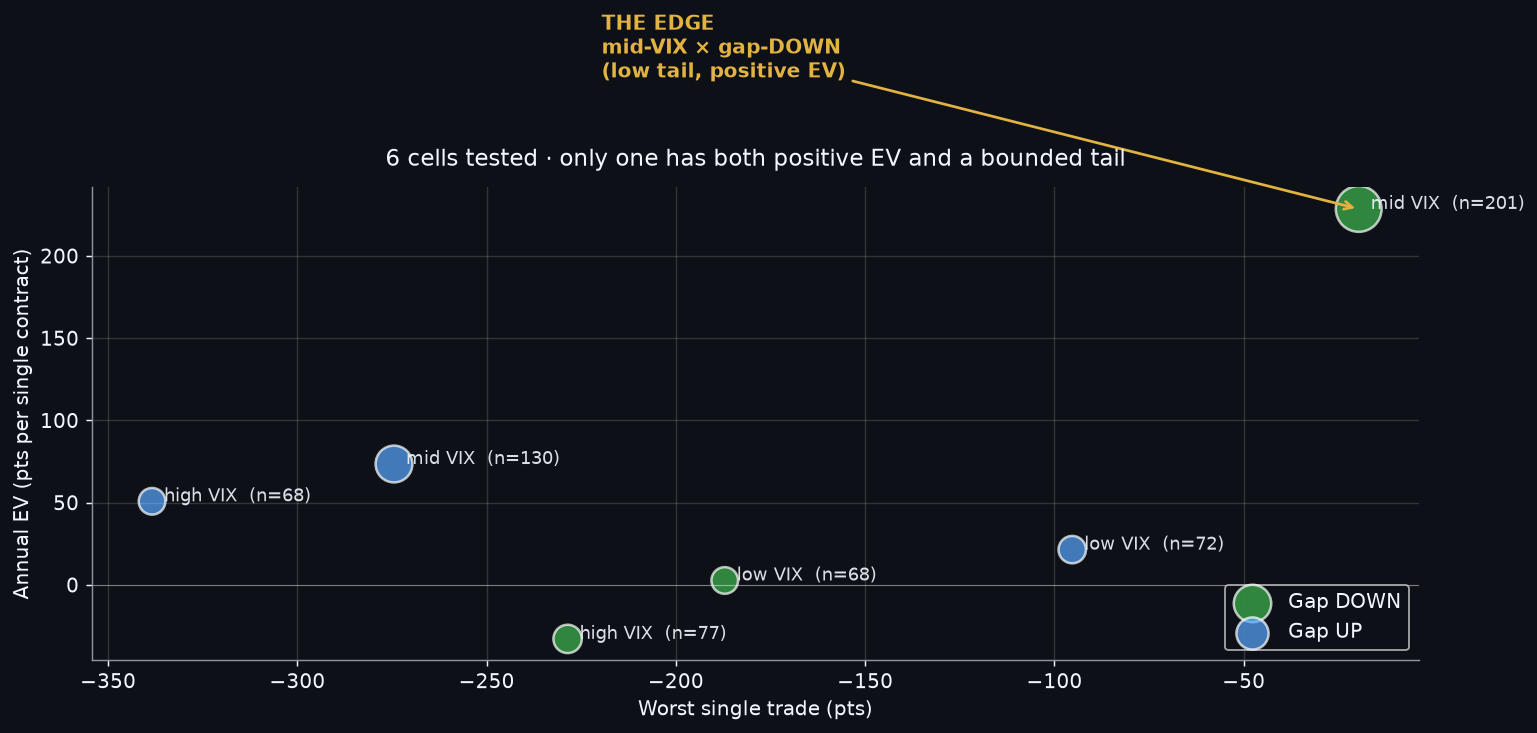

In [5]:
# Stratify the FULL universe of 0.75x events by VIX × direction.
# Each cell shows: how many events/yr, total annual EV, worst trade.
ue = us_events.copy()
s = ue.groupby(["vix_regime", "direction"]).agg(
    n         = ("eod_pnl", "size"),
    annual_ev = ("eod_pnl", lambda x: x.sum() / 7),
    worst     = ("eod_pnl", "min"),
).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
for direction, color, label in [("gap_down", GREEN, "Gap DOWN"), ("gap_up", BLUE, "Gap UP")]:
    sub = s[s["direction"] == direction]
    ax.scatter(sub["worst"], sub["annual_ev"], s=sub["n"]*3.2, alpha=0.7,
               c=color, edgecolor="white", linewidths=1.4, label=label)
    for _, r in sub.iterrows():
        ax.annotate(f"  {r['vix_regime']} VIX  (n={int(r['n'])})",
                    (r["worst"], r["annual_ev"]),
                    fontsize=10, color=WHITE, alpha=0.9)

ax.axhline(0, color="white", lw=0.5, alpha=0.4)

# Highlight the winning cells (mid-VIX × gap_down)
target = s[(s["vix_regime"]=="mid") & (s["direction"]=="gap_down")].iloc[0]
ax.annotate("THE EDGE\nmid-VIX × gap-DOWN\n(low tail, positive EV)",
            xy=(target["worst"], target["annual_ev"]),
            xytext=(target["worst"]-200, target["annual_ev"]+80),
            fontsize=11, color=GOLD, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=GOLD, lw=1.5))

ax.set_xlabel("Worst single trade (pts)")
ax.set_ylabel("Annual EV (pts per single contract)")
ax.set_title("6 cells tested · only one has both positive EV and a bounded tail",
             fontsize=13, pad=12)
ax.legend(loc="lower right")
ax.grid(alpha=0.15)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("charts/p11_04_r1.png", dpi=140, bbox_inches="tight", facecolor=BG)
plt.show()


**An entire row stood out** — not one cherry-picked cell. *Mid-VIX × gap_DOWN* was clean in both alignment sub-cells, and the same pattern held across all four US instruments independently. Across the row: 201 events, 94% win rate, worst trade in 7 years −$20.

The filter cut frequency in half. Cut the tail by 17×.


## Step 4 · But the trade I started with was a gap UP

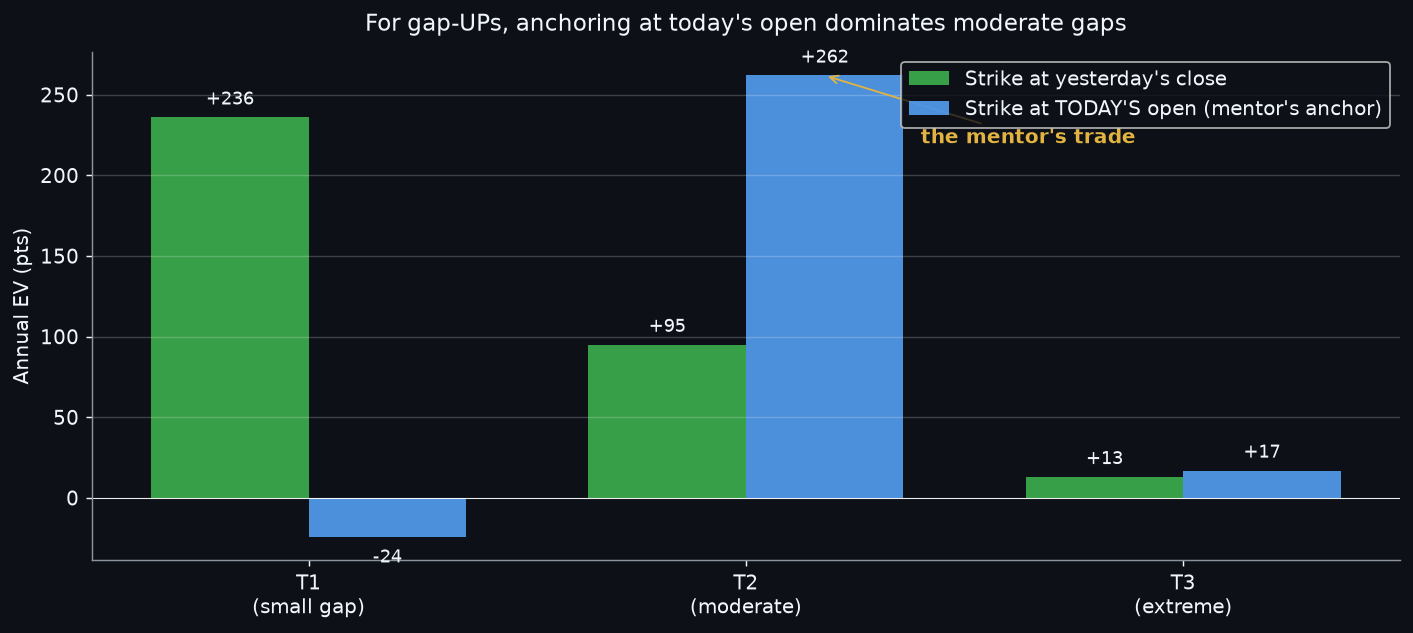

In [6]:
# Show MR vs MOM by tier — pre-computed bar
fig, ax = plt.subplots(figsize=(11, 5))
tiers = ["T1\n(small gap)", "T2\n(moderate)", "T3\n(extreme)"]
mr_vals  = [236, 95, 13]
mom_vals = [-24, 262, 17]

x = np.arange(len(tiers)); w = 0.36
b1 = ax.bar(x - w/2, mr_vals,  w, label="Strike at yesterday's close", color=GREEN, alpha=0.85)
b2 = ax.bar(x + w/2, mom_vals, w, label="Strike at TODAY'S open (mentor's anchor)", color=BLUE, alpha=0.85)
ax.axhline(0, color="white", lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(tiers, fontsize=11)
ax.set_ylabel("Annual EV (pts)")
ax.set_title("For gap-UPs, anchoring at today's open dominates moderate gaps",
             fontsize=13, pad=12)
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.2)
for bar, v in zip(b1, mr_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v + (8 if v>=0 else -16),
            f"{v:+d}", ha="center", fontsize=10)
for bar, v in zip(b2, mom_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v + (8 if v>=0 else -16),
            f"{v:+d}", ha="center", fontsize=10)

# Annotate the highlight
ax.annotate("the mentor's trade",
            xy=(1 + w/2, 262), xytext=(1.4, 220),
            fontsize=11, color=GOLD, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=GOLD))

ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("charts/p11_05_m1.png", dpi=140, bbox_inches="tight", facecolor=BG)
plt.show()


Tested both strike anchors for gap-ups. On moderate gaps, **anchoring at today's open beats anchoring at yesterday's close by 4×**.

That's the exact structure of the trade I'd been investigating. **His instinct was calibrated.**


## Step 5 · Diversification (the unexpected part)

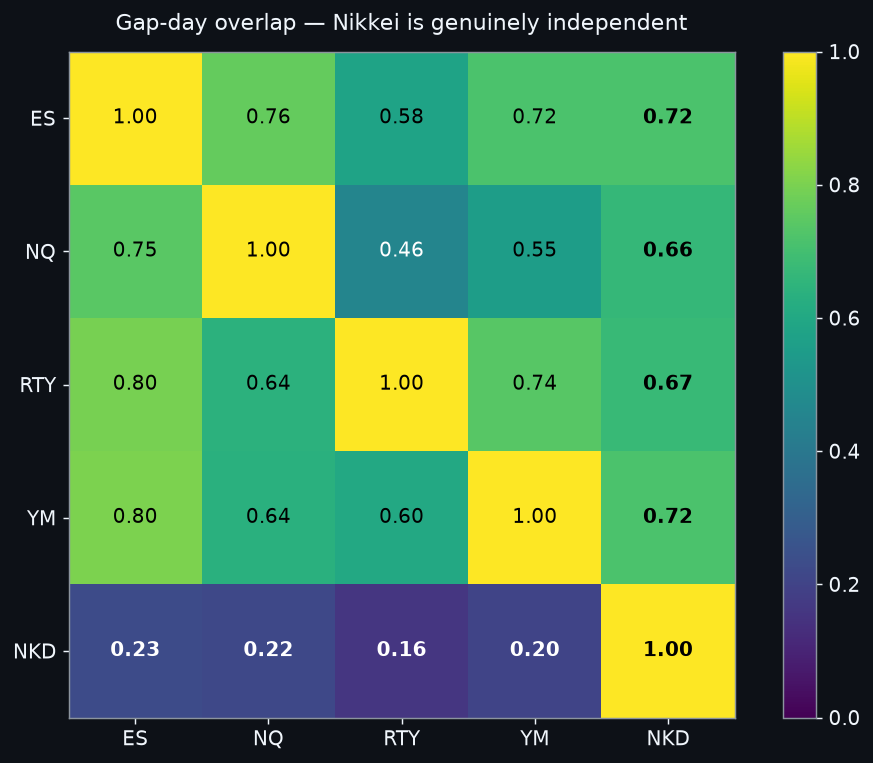

In [7]:
SYMBOLS = ["ES", "NQ", "RTY", "YM", "NKD"]
ev_dated = events.copy()
ev_dated["date"] = pd.to_datetime(ev_dated["date"])

def days(s):
    return set(ev_dated[ev_dated["symbol"]==s]["date"].dt.date.unique())

n = len(SYMBOLS)
frac = np.zeros((n, n))
for i, a in enumerate(SYMBOLS):
    da = days(a)
    for j, b in enumerate(SYMBOLS):
        db = days(b)
        frac[i, j] = len(da & db) / max(len(da), 1)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(frac, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(SYMBOLS, fontsize=11)
ax.set_yticks(range(n)); ax.set_yticklabels(SYMBOLS, fontsize=11)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{frac[i,j]:.2f}", ha="center", va="center",
                color="black" if frac[i,j] > 0.5 else "white", fontsize=11,
                fontweight="bold" if i==4 or j==4 else "normal")
ax.set_title("Gap-day overlap — Nikkei is genuinely independent", fontsize=12, pad=12)
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig("charts/p11_06_diversify.png", dpi=140, bbox_inches="tight", facecolor=BG)
plt.show()


US futures gap on the same news 70–80% of the time. Adding more US instruments isn't diversification — it's leverage.

**Nikkei gaps on Asian news.** 22% overlap with US. Independent signal — and it ended up carrying half the strategy's yield.


## What It Adds Up To

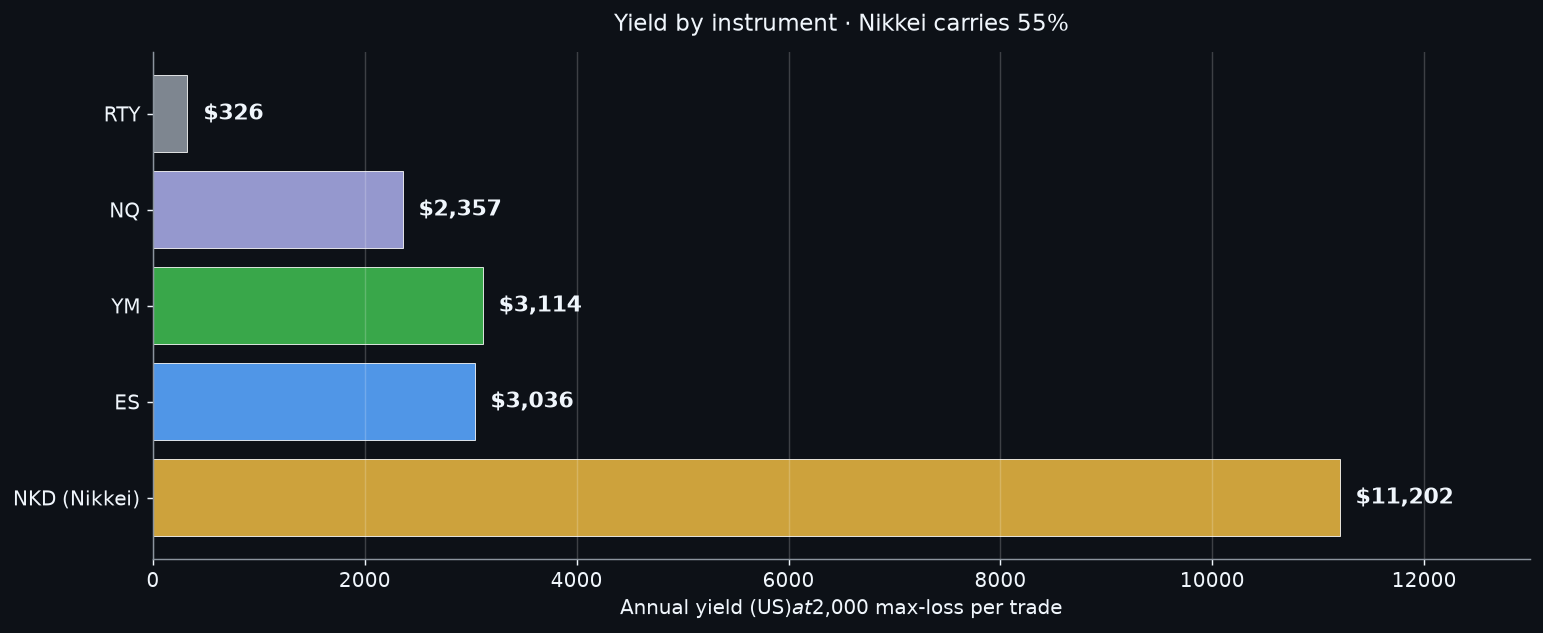

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
data = [
    ("NKD (Nikkei)", 8542 + 2660, GOLD),
    ("ES",   1513 + 1523, BLUE),
    ("YM",   1512 + 1602, GREEN),
    ("NQ",    596 + 1761, "#a5a8e3"),
    ("RTY",   113 +  213, GREY),
]
labels = [d[0] for d in data]
vals   = [d[1] for d in data]
colors = [d[2] for d in data]
bars = ax.barh(labels, vals, color=colors, alpha=0.9, edgecolor="white", linewidth=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_width() + 150, bar.get_y() + bar.get_height()/2,
            f"${v:,.0f}", va="center", fontsize=12, color=WHITE, fontweight="bold")
ax.set_xlim(0, 13000)
ax.set_xlabel("Annual yield (US$) at $2,000 max-loss per trade")
ax.set_title("Yield by instrument · Nikkei carries 55%", fontsize=13, pad=12)
ax.grid(axis="x", alpha=0.2)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("charts/p11_07_yield.png", dpi=140, bbox_inches="tight", facecolor=BG)
plt.show()


~77 trade signals / year · ~$14,000 model EV at aggressive sizing · worst trade capped at $2,000 by structure.

About **$7 of expected annual yield for every $1 at risk on a single bad trade.**


## The Honest Test — Did It Survive Out-of-Sample?

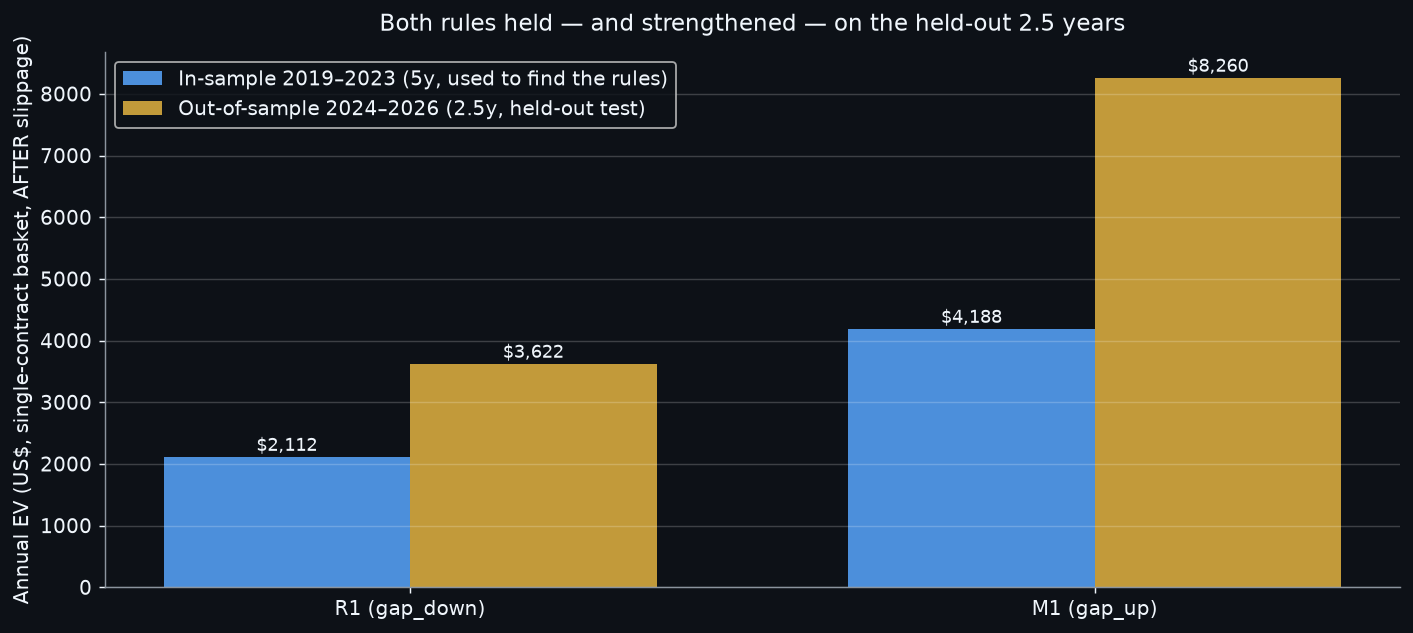

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
rules = ["R1 (gap_down)", "M1 (gap_up)"]
is_vals  = [2112, 4188]
oos_vals = [3622, 8260]

x = np.arange(len(rules)); w = 0.36
b1 = ax.bar(x - w/2, is_vals,  w, label="In-sample 2019–2023 (5y, used to find the rules)",
            color=BLUE, alpha=0.85)
b2 = ax.bar(x + w/2, oos_vals, w, label="Out-of-sample 2024–2026 (2.5y, held-out test)",
            color=GOLD, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(rules, fontsize=11)
ax.set_ylabel("Annual EV (US$, single-contract basket, AFTER slippage)")
ax.set_title("Both rules held — and strengthened — on the held-out 2.5 years",
             fontsize=13, pad=12)
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.2)
for bars, vals in [(b1, is_vals), (b2, oos_vals)]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v + 100,
                f"${v:,}", ha="center", fontsize=10)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("charts/p11_08_walkforward.png", dpi=140, bbox_inches="tight", facecolor=BG)
plt.show()


Trained on 2019–2023. Tested on 2024–2026 *without re-fitting*. Both rules survived; both improved.

That's the answer to "did you data-mine the result." The discovery period is half the sample. The other half is untouched and still pays.

**One honest casualty from this test:** RTY (Russell 2000 futures) lost money on the held-out 2.5 years (5% win rate after slippage). **Dropping RTY from the production universe.** The four remaining instruments (ES, NQ, YM, NKD) carry the entire result.


## What This Still Doesn't Tell Me

- Sample window covers COVID 2020 but not 2008 or 1998.
- BS pricing ignores real put-side skew — model EV is 10–15% optimistic before friction.
- Paper-trading hasn't started yet. Backtests flatter; markets humble.

Paper-trading begins July 1. Real numbers in 90 days.

---

*The research trail — every dead end, every test — is in notebooks 01 through 10. This page is the elevator pitch.*
